# SofaScore overall score reflection

Compare the newest pre-match score with the newest post-match KBStats snapshot. Every rostered player is evaluated, including non-appearances as zero points. Club identifiers are not displayed.

In [1]:
import importlib
import sys
from datetime import datetime
from pathlib import Path

import html
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

def locate_project_root() -> Path:
    for start in (Path.cwd().resolve(), Path(globals().get('__vsc_ipynb_file__', '.')).resolve()):
        for candidate in (start, *start.parents):
            if (candidate / 'project_paths.py').is_file():
                return candidate
    raise FileNotFoundError('Could not locate project_paths.py.')

PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import sofascore_score_reflection as score_reflection
importlib.reload(score_reflection)  # pick up local helper changes without restarting the kernel

from sofascore_score_reflection import (
    BASELINE_PATH, accuracy_metrics, baseline_from_snapshot, build_outcomes,
    feature_frame, load_baseline, persist_baseline,
    reconstruct_source_chances, select_reflection_inputs,
)

## Current-score settings

These values reconstruct the score exactly as it was created. They are fixed for reflection; model fitting and weight tuning are deferred until several completed matchdays are available.

In [2]:
QUESTIONABLE_INJURY_PENALTY = 0.15
ALTERNATIVE_STARTING_CHANCE_DECAY = 0.45

## Load pre- and post-match data

Enter the local retrieval date shown in the export filename (`YYYY-MM-DD`) for each input. The latest file retrieved on each selected date is used. Press Enter for either prompt to retain the previous newest-available behaviour. The selected KBStats snapshot must be later than the expected-points export. Each raw lineup snapshot must be at or before score creation, preventing future information entering the reflection.

In [3]:
def choose_retrieval_date(label: str) -> str | None:
    value = input(
        f'{label} retrieval date (YYYY-MM-DD; press Enter for latest available): '
    ).strip()
    if not value:
        return None
    try:
        return datetime.strptime(value, '%Y-%m-%d').date().isoformat()
    except ValueError as exc:
        raise ValueError(f'{label} retrieval date must be YYYY-MM-DD, for example 2026-08-31.') from exc

EXPECTED_POINTS_RETRIEVAL_DATE = choose_retrieval_date('Expected-points')
KBSTATS_RETRIEVAL_DATE = choose_retrieval_date('KBStats')
print(
    'Selection: expected-points = ' + (EXPECTED_POINTS_RETRIEVAL_DATE or 'latest available')
    + '; KBStats = ' + (KBSTATS_RETRIEVAL_DATE or 'latest available')
)

Expected-points retrieval date (YYYY-MM-DD; press Enter for latest available):  2026-08-28
KBStats retrieval date (YYYY-MM-DD; press Enter for latest available):  


Selection: expected-points = 2026-08-28; KBStats = latest available


In [4]:
INPUTS = select_reflection_inputs(
    expected_retrieval_date=EXPECTED_POINTS_RETRIEVAL_DATE,
    kbstats_retrieval_date=KBSTATS_RETRIEVAL_DATE,
)
EXPECTED = pd.read_csv(INPUTS.expected_path, encoding='utf-8-sig')
CURRENT = pd.read_csv(INPUTS.kbstats_path, encoding='utf-8-sig')
BASELINE = load_baseline()

display(pd.DataFrame([{
    'expected-points selection': EXPECTED_POINTS_RETRIEVAL_DATE or 'latest available',
    'KBStats selection': KBSTATS_RETRIEVAL_DATE or 'latest available',
    'expected_score_file': INPUTS.expected_path.name,
    'post_match_kbstats_file': INPUTS.kbstats_path.name,
    'baseline_file': str(BASELINE_PATH.relative_to(PROJECT_ROOT)),
    'baseline_rows': len(BASELINE),
    'lineup_snapshots': ', '.join(path.name for path in INPUTS.lineup_paths.values()),
}]))

,expected-points selection,KBStats selection,expected_score_file,post_match_kbstats_file,baseline_file,baseline_rows,lineup_snapshots
0,2026-08-28,latest available,expected_points_20260828_120706_+0200_sofascor...,kbstats_players_20260831_111715_+0200.csv,data\reference\kbstats_player_match_baseline.csv,0,ligainsider_bundesliga_lineups_20260828_120913...


## Actual outcomes

KBStats keeps cumulative appearances, starts, points, and playing time. The saved baseline converts those cumulative totals into last-matchday values; playing time is displayed in minutes. On the first run or after a counter reset, the latest history entry is used as a safe fallback for appearance and points.

In [5]:
OUTCOMES = build_outcomes(CURRENT, BASELINE)
display(OUTCOMES['outcome_status'].value_counts(dropna=False).rename_axis('outcome_status').reset_index(name='players'))
display(OUTCOMES[['actual_points', 'minutes_played', 'played', 'started']].agg(['count', 'mean', 'sum']).round(3))

,outcome_status,players
0,no_baseline,469


,actual_points,minutes_played,played,started
count,469.000,469.000,469.000,469.000
mean,46.239,40.867,0.608,0.422
sum,21686.000,19166.650,285.000,198.000


## Current-score accuracy

The analysis uses the original raw pre-match score, without scaling it from the realised matchday outcomes. MAE and RMSE therefore describe the raw score's distance from actual Kickbase points; R² measures explained variation, Spearman measures ranking quality, and top-decile precision tests predicted high scorers.

In [6]:
SOURCE_CHANCES = reconstruct_source_chances(
    INPUTS, QUESTIONABLE_INJURY_PENALTY, ALTERNATIVE_STARTING_CHANCE_DECAY
)
ANALYSIS = feature_frame(EXPECTED, CURRENT, SOURCE_CHANCES).merge(OUTCOMES, on='player_id', how='left', validate='one_to_one')
ANALYSIS['actual_points'] = ANALYSIS['actual_points'].fillna(0.0)
ANALYSIS['prediction'] = ANALYSIS['score']
CURRENT_METRICS = accuracy_metrics(ANALYSIS['actual_points'], ANALYSIS['prediction'])
display(pd.DataFrame([CURRENT_METRICS], index=['current score']).round(3))

DETAIL_COLUMNS = [
    'prediction', 'actual_points', 'minutes_played',
    'sofascore_average_rating', 'expected_match_points', 'starting_chance',
    'ligainsider_chance', 'kickbase_chance', 'kicker_chance', 'rotowire_chance',
    'questionable_injury_penalty', 'played', 'started',
]
DETAIL_LABELS = {
    'prediction': 'Raw-score prediction',
    'actual_points': 'Actual points', 'minutes_played': 'Minutes played',
    'sofascore_average_rating': 'SofaScore average rating',
    'expected_match_points': 'Expected match points (odds)', 'starting_chance': 'Original starting chance',
    'ligainsider_chance': 'LigaInsider starting chance', 'kickbase_chance': 'Kickbase starting chance',
    'kicker_chance': 'Kicker starting chance', 'rotowire_chance': 'RotoWire starting chance',
    'questionable_injury_penalty': 'Questionable-player penalty', 'played': 'Played', 'started': 'Started',
}

def player_details(row):
    def pretty(column):
        value = row[column]
        if column in {'played', 'started'}:
            return 'Unknown' if pd.isna(value) else ('Yes' if bool(value) else 'No')
        if pd.isna(value):
            return 'Unavailable'
        return f'{float(value):.2f}'
    rows = ''.join(
        f'<tr><th style="text-align:left;padding:3px 18px 3px 0;">{DETAIL_LABELS[column]}</th>'
        f'<td style="padding:3px 0;">{pretty(column)}</td></tr>'
        for column in DETAIL_COLUMNS
    )
    return (
        '<div style="border:1px solid #d0d7de;border-radius:8px;padding:12px 16px;margin-top:10px;max-width:540px;">'
        f'<strong style="font-size:16px;">{html.escape(str(row["name"]))}</strong>'
        f'<table style="margin-top:7px;border-collapse:collapse;">{rows}</table></div>'
    )

details_panel = widgets.HTML("<em>Hover over a dot to see that player's score breakdown.</em>")
scatter = go.Scatter(
    x=ANALYSIS['prediction'], y=ANALYSIS['actual_points'],
    mode='markers', marker={'size': 9, 'color': '#1f77b4', 'opacity': 0.72},
    hovertemplate='Hover for player details<extra></extra>',
)
interactive_figure = go.FigureWidget(data=[scatter])
interactive_figure.update_layout(
    title='Raw score versus actual', xaxis_title='Raw pre-match score',
    yaxis_title='Actual points', height=480, margin={'l': 55, 'r': 25, 't': 55, 'b': 55},
)

def show_player_details(trace, points, state):
    if points.point_inds:
        details_panel.value = player_details(ANALYSIS.iloc[points.point_inds[0]])

interactive_figure.data[0].on_hover(show_player_details)
display(widgets.VBox([interactive_figure, details_panel]))

,mae,rmse,r2,spearman_correlation,top_decile_precision
current score,45.518,79.15,-0.271,0.659,0.383


    'data': [{'hovertemplate': 'Hover for player details<extra></extra>',
      …

## Actual points versus SofaScore rating, grouped by expected match points

Each dot is one rostered player. The four charts split players into equal-sized packs based on pre-match, odds-derived expected match points. The horizontal axis is pre-match SofaScore average rating and the vertical axis is actual post-match Kickbase points. Shared axis ranges make the four packs directly comparable.

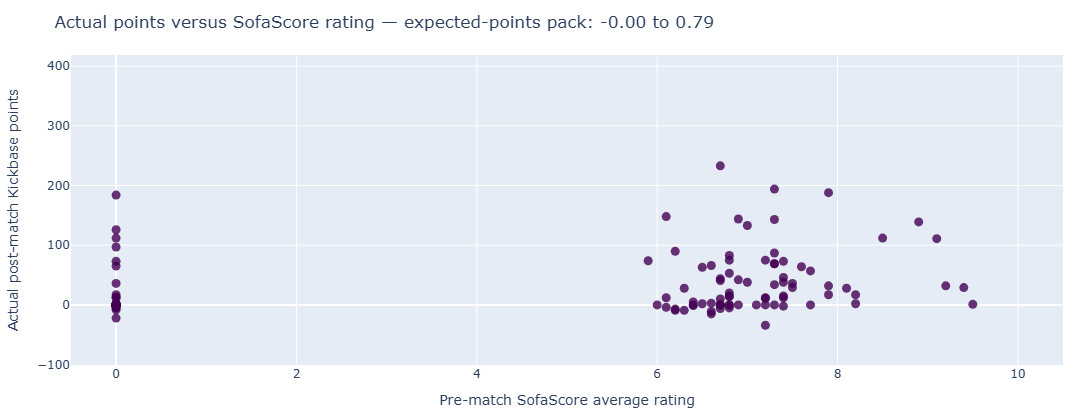

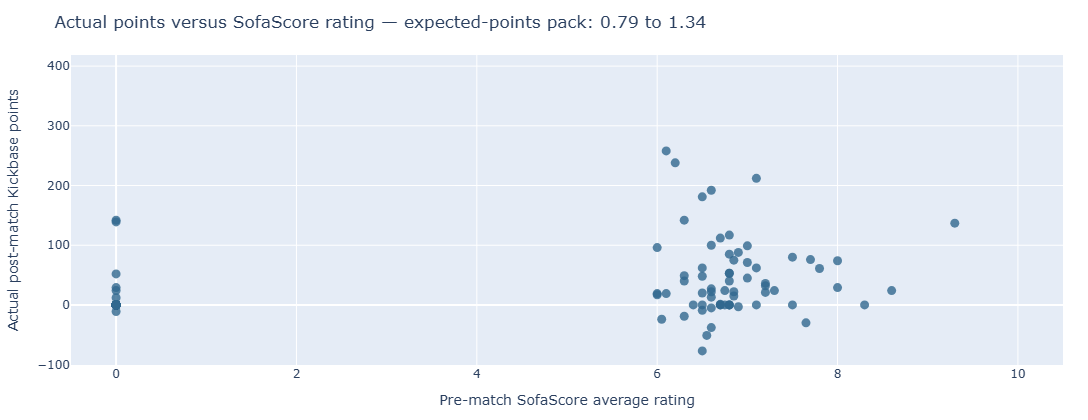

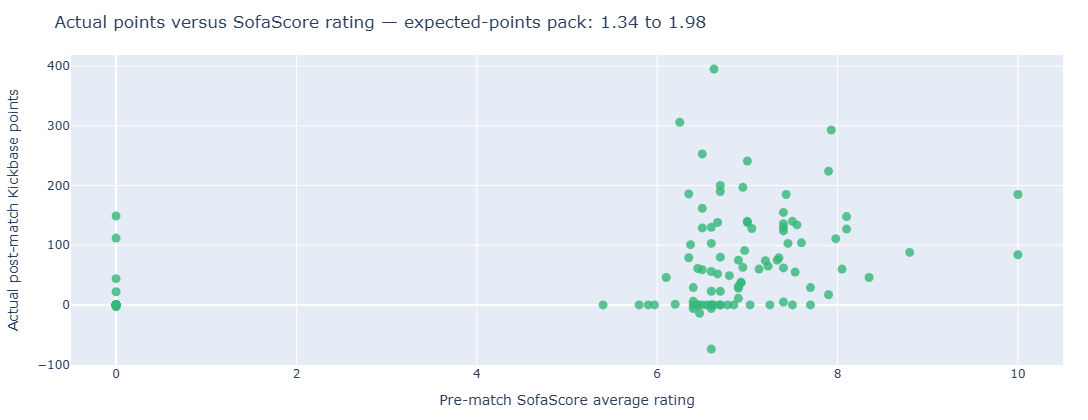

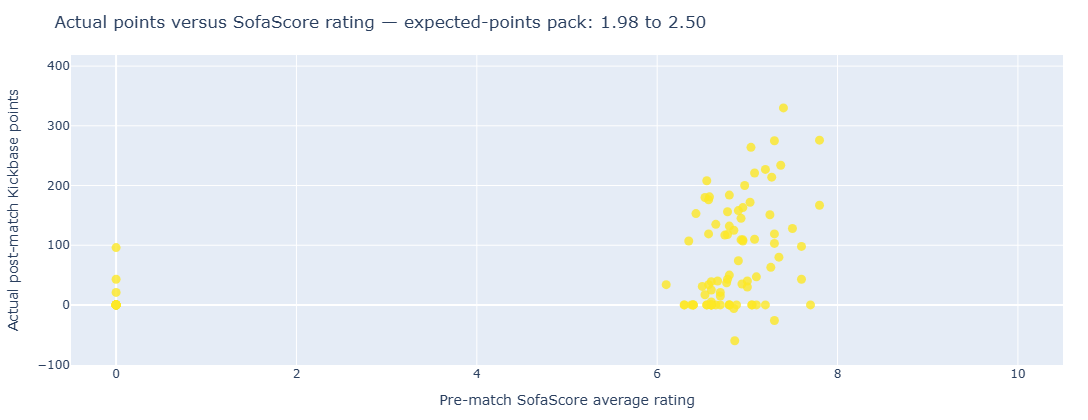

In [7]:
EXPECTED_POINTS_PACK_COLORS = ['#440154', '#31688e', '#35b779', '#fde725']
SCORE_RATING_ODDS_PLOT = ANALYSIS.copy()
SCORE_RATING_ODDS_PLOT['expected_points_pack'] = pd.qcut(
    SCORE_RATING_ODDS_PLOT['expected_match_points'], q=4, duplicates='drop'
)

def component_axis_range(values):
    minimum = float(values.min())
    maximum = float(values.max())
    padding = max((maximum - minimum) * 0.05, 0.1)
    return [minimum - padding, maximum + padding]

ACTUAL_POINTS_COMPONENT_RANGE = component_axis_range(SCORE_RATING_ODDS_PLOT['actual_points'])
RATING_COMPONENT_RANGE = component_axis_range(SCORE_RATING_ODDS_PLOT['sofascore_average_rating'])
EXPECTED_POINTS_PACKS = SCORE_RATING_ODDS_PLOT['expected_points_pack'].cat.categories

for pack_index, expected_points_pack in enumerate(EXPECTED_POINTS_PACKS):
    players_in_pack = SCORE_RATING_ODDS_PLOT.loc[
        SCORE_RATING_ODDS_PLOT['expected_points_pack'].eq(expected_points_pack)
    ]
    pack_label = f'{expected_points_pack.left:.2f} to {expected_points_pack.right:.2f}'
    score_rating_odds_figure = go.Figure(go.Scatter(
        x=players_in_pack['sofascore_average_rating'],
        y=players_in_pack['actual_points'],
        mode='markers',
        text=players_in_pack['name'],
        customdata=players_in_pack[[
            'expected_match_points', 'prediction', 'starting_chance',
            'ligainsider_chance', 'kickbase_chance', 'kicker_chance', 'rotowire_chance',
        ]],
        marker={'size': 9, 'opacity': 0.8, 'color': EXPECTED_POINTS_PACK_COLORS[pack_index]},
        hovertemplate=(
            '<b>%{text}</b><br>'
            'SofaScore average rating: %{x:.2f}<br>'
            'Actual post-match points: %{y:.2f}<br>'
            'Expected match points (odds): %{customdata[0]:.2f}<br>'
            'Raw pre-match score: %{customdata[1]:.2f}<br>'
            'Starting chance: %{customdata[2]:.2f}<br>'
            'LigaInsider chance: %{customdata[3]:.2f}<br>'
            'Kickbase chance: %{customdata[4]:.2f}<br>'
            'Kicker chance: %{customdata[5]:.2f}<br>'
            'RotoWire chance: %{customdata[6]:.2f}<extra></extra>'
        ),
    ))
    score_rating_odds_figure.update_layout(
        title=f'Actual points versus SofaScore rating — expected-points pack: {pack_label}',
        xaxis_title='Pre-match SofaScore average rating',
        yaxis_title='Actual post-match Kickbase points',
        height=420, margin={'l': 60, 'r': 25, 't': 55, 'b': 55},
    )
    score_rating_odds_figure.update_xaxes(range=RATING_COMPONENT_RANGE)
    score_rating_odds_figure.update_yaxes(range=ACTUAL_POINTS_COMPONENT_RANGE)
    score_rating_odds_figure.show()

## Expected match points versus actual points, by position

Each dot is one player. The horizontal axis is the pre-match expected-match-points value; the vertical axis is the actual Kickbase points. Players with zero predicted starting chance who did not appear are excluded; all other players remain. The charts separate goalkeepers, defenders, midfielders, and forwards. Hover a dot for the player and matchday outcome details.

Excluded 169 expected non-appearances from the position charts.


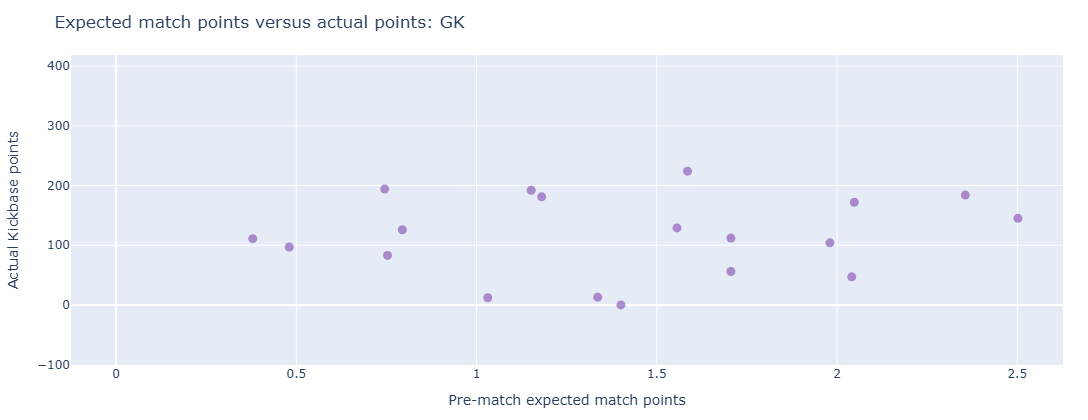

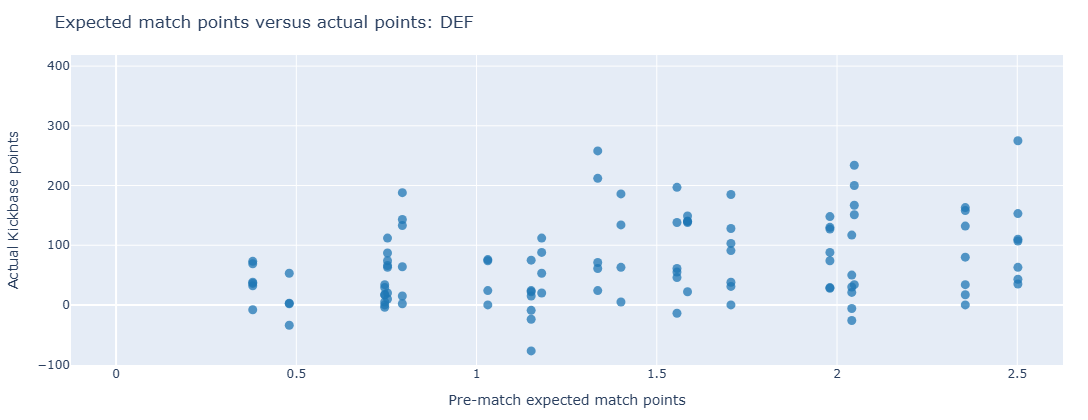

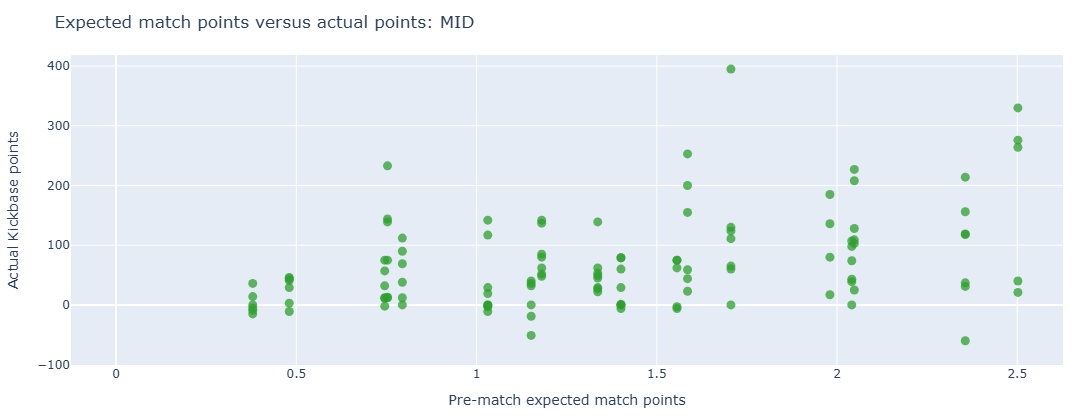

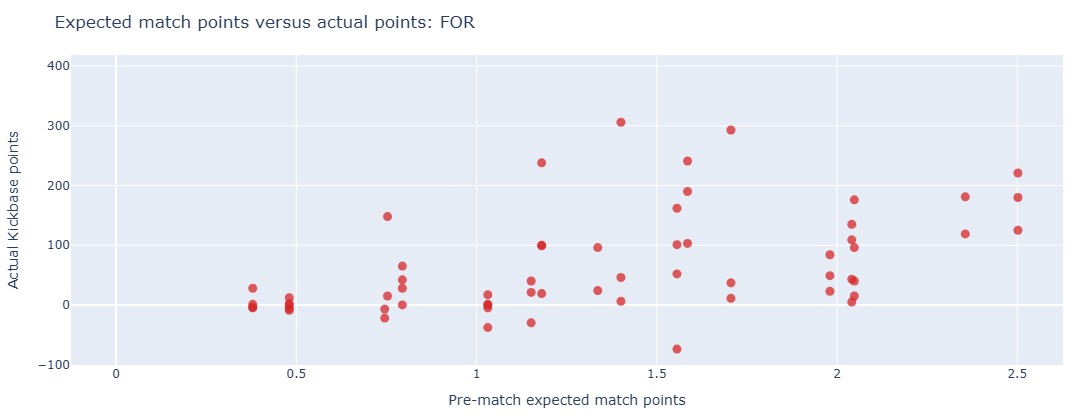

In [8]:
POSITION_LABELS = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FOR'}
POSITION_ORDER = ['GK', 'DEF', 'MID', 'FOR']
POSITION_COLORS = {'GK': '#9467bd', 'DEF': '#1f77b4', 'MID': '#2ca02c', 'FOR': '#d62728'}
EXCLUDED_FROM_EXPECTED_POINTS_PLOT = ANALYSIS['starting_chance'].le(0) & ANALYSIS['played'].eq(False)
EXPECTED_POINTS_PLOT = ANALYSIS.loc[~EXCLUDED_FROM_EXPECTED_POINTS_PLOT].copy()
print(f"Excluded {EXCLUDED_FROM_EXPECTED_POINTS_PLOT.sum()} expected non-appearances from the position charts.")
EXPECTED_POINTS_PLOT['position_group'] = (
    pd.to_numeric(EXPECTED_POINTS_PLOT['position'], errors='coerce').map(POSITION_LABELS).fillna('Unknown')
)

def padded_axis_range(values):
    minimum = float(values.min())
    maximum = float(values.max())
    padding = max((maximum - minimum) * 0.05, 0.1)
    return [minimum - padding, maximum + padding]

EXPECTED_POINTS_AXIS_RANGE = padded_axis_range(EXPECTED_POINTS_PLOT['expected_match_points'])
ACTUAL_POINTS_AXIS_RANGE = padded_axis_range(EXPECTED_POINTS_PLOT['actual_points'])

for position_group in POSITION_ORDER:
    players_at_position = EXPECTED_POINTS_PLOT.loc[
        EXPECTED_POINTS_PLOT['position_group'].eq(position_group)
    ]
    if players_at_position.empty:
        continue
    position_figure = go.Figure(go.Scatter(
        x=players_at_position['expected_match_points'],
        y=players_at_position['actual_points'],
        mode='markers',
        name=position_group,
        text=players_at_position['name'],
        customdata=players_at_position[[
            'prediction', 'sofascore_average_rating', 'starting_chance',
            'played', 'started', 'minutes_played',
        ]],
        marker={'size': 9, 'color': POSITION_COLORS.get(position_group, '#7f7f7f'), 'opacity': 0.75},
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Position: ' + position_group + '<br>'
            'Expected match points: %{x:.2f}<br>'
            'Actual points: %{y:.2f}<br>'
            'Raw score: %{customdata[0]:.2f}<br>'
            'SofaScore average rating: %{customdata[1]:.2f}<br>'
            'Starting chance: %{customdata[2]:.2f}<br>'
            'Played: %{customdata[3]}<br>'
            'Started: %{customdata[4]}<br>'
            'Minutes played: %{customdata[5]:.2f}<extra></extra>'
        ),
    ))

    position_figure.update_layout(
        title=f'Expected match points versus actual points: {position_group}',
        xaxis_title='Pre-match expected match points',
        yaxis_title='Actual Kickbase points',
        showlegend=False, height=420,
        margin={'l': 60, 'r': 25, 't': 55, 'b': 55},
    )
    position_figure.update_xaxes(range=EXPECTED_POINTS_AXIS_RANGE)
    position_figure.update_yaxes(range=ACTUAL_POINTS_AXIS_RANGE)
    position_figure.show()

## Accuracy after excluding expected non-appearances

This view excludes only players whose pre-match starting chance was zero and who did not play. It keeps players who had some chance of starting, including those who ultimately did not appear, because those are meaningful prediction outcomes.

In [9]:
EXPECTED_NON_APPEARANCE = ANALYSIS['starting_chance'].le(0) & ANALYSIS['played'].eq(False)
EVALUATED_WHEN_EXPECTED = ANALYSIS.loc[~EXPECTED_NON_APPEARANCE].copy()
if len(EVALUATED_WHEN_EXPECTED) < 10:
    raise ValueError('Too few players remain after excluding expected non-appearances.')

EXPECTED_APPEARANCE_METRICS = accuracy_metrics(
    EVALUATED_WHEN_EXPECTED['actual_points'], EVALUATED_WHEN_EXPECTED['prediction']
)
display(pd.DataFrame([EXPECTED_APPEARANCE_METRICS], index=['excluding expected non-appearances']).round(3))
print(f"Excluded {EXPECTED_NON_APPEARANCE.sum()} of {len(ANALYSIS)} players: zero predicted starting chance and no appearance.")

filtered_details_panel = widgets.HTML("<em>Hover over a dot to see that player's score breakdown.</em>")
filtered_scatter = go.Scatter(
    x=EVALUATED_WHEN_EXPECTED['prediction'], y=EVALUATED_WHEN_EXPECTED['actual_points'],
    mode='markers', marker={'size': 9, 'color': '#1f77b4', 'opacity': 0.72},
    hovertemplate='Hover for player details<extra></extra>',
)
filtered_figure = go.FigureWidget(data=[filtered_scatter])
filtered_figure.update_layout(
    title='Raw score versus actual: excluding expected non-appearances',
    xaxis_title='Raw pre-match score', yaxis_title='Actual points',
    height=480, margin={'l': 55, 'r': 25, 't': 55, 'b': 55},
)

def show_filtered_player_details(trace, points, state):
    if points.point_inds:
        filtered_details_panel.value = player_details(EVALUATED_WHEN_EXPECTED.iloc[points.point_inds[0]])

filtered_figure.data[0].on_hover(show_filtered_player_details)
display(widgets.VBox([filtered_figure, filtered_details_panel]))

,mae,rmse,r2,spearman_correlation,top_decile_precision
excluding expected non-appearances,71.16,98.964,-0.682,0.487,0.233


Excluded 169 of 469 players: zero predicted starting chance and no appearance.


    'data': [{'hovertemplate': 'Hover for player details<extra></extra>',
      …

## How accurate were the lineup sources?

Each provider's saved pre-match starting chance is compared with the actual start outcome. No club identifiers are displayed.

- **Brier score (lower better):** the average squared gap between a starting chance and what happened (`1` for a starter, `0` otherwise). `0` is perfect. A source that assigns high chances to players who do not start, or low chances to players who do, receives a worse score. It assesses whether the probabilities themselves are realistic.
- **ROC-AUC (higher better):** whether actual starters are ranked above non-starters, regardless of the numeric probability scale. `1.00` is perfect, `0.50` is no better than random ordering, and below `0.50` means the ordering is counterproductive.
- **Predicted starters at the threshold:** players with a chance at least `STARTING_CHANCE_THRESHOLD` (initially `0.50`) are treated as the source's predicted starters. Change that input if you want a stricter or looser definition.
- **Precision at the threshold (higher better):** among the players the source predicted to start, the share who actually started.
- **Recall at the threshold (higher better):** among all actual starters, the share that the source predicted to start. Precision and recall trade off: lowering the threshold normally improves recall but can reduce precision.
- **Top-11 eligible teams:** number of teams where that source supplied at least eleven positive-chance candidates. The top-11 metric deliberately excludes incomplete source coverage.
- **Top-11 hit rate (higher better):** for each eligible team, the source's eleven highest-chance players are selected. The hit rate is the share of those selections who actually started. This is the most direct answer to “how close was the predicted starting XI?”
- **Mean chance for actual starters / non-starters:** these should be clearly separated, with the starter average higher. A small gap indicates weak discrimination.

This is one matchday only, so use the table to compare sources descriptively rather than to declare a permanent winner.

In [10]:
from sklearn.metrics import roc_auc_score

STARTING_CHANCE_THRESHOLD = 0.50
LINEUP_SOURCES = {
    'LigaInsider': 'ligainsider_chance',
    'Kickbase': 'kickbase_chance',
    'Kicker': 'kicker_chance',
    'RotoWire': 'rotowire_chance',
}
STARTER_EVALUATION = ANALYSIS.loc[ANALYSIS['started'].notna()].copy()
if STARTER_EVALUATION.empty or STARTER_EVALUATION['started'].nunique() != 2:
    raise ValueError('Starter evaluation needs known examples of both starters and non-starters.')
STARTER_EVALUATION['actual_started'] = STARTER_EVALUATION['started'].astype(int)

def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else float('nan')

source_rows = []
for source_name, chance_column in LINEUP_SOURCES.items():
    chance = STARTER_EVALUATION[chance_column].clip(0.0, 1.0)
    actual = STARTER_EVALUATION['actual_started']
    predicted = chance.ge(STARTING_CHANCE_THRESHOLD)
    true_positive = int((predicted & actual.eq(1)).sum())
    false_positive = int((predicted & actual.eq(0)).sum())
    false_negative = int((~predicted & actual.eq(1)).sum())

    top_11_hits = 0
    top_11_teams = 0
    for _, team_rows in STARTER_EVALUATION.assign(_chance=chance).groupby('teamId', sort=False):
        candidates = team_rows.loc[team_rows['_chance'].gt(0)]
        if len(candidates) >= 11:
            top_11_hits += int(candidates.nlargest(11, '_chance')['actual_started'].sum())
            top_11_teams += 1

    source_rows.append({
        'source': source_name,
        'evaluated players': len(STARTER_EVALUATION),
        'Brier score (lower better)': ((chance - actual) ** 2).mean(),
        'ROC-AUC (higher better)': roc_auc_score(actual, chance),
        f'predicted starters (≥ {STARTING_CHANCE_THRESHOLD:.2f})': int(predicted.sum()),
        f'precision (≥ {STARTING_CHANCE_THRESHOLD:.2f})': safe_ratio(true_positive, true_positive + false_positive),
        f'recall (≥ {STARTING_CHANCE_THRESHOLD:.2f})': safe_ratio(true_positive, true_positive + false_negative),
        'top-11 eligible teams': top_11_teams,
        'top-11 hit rate': safe_ratio(top_11_hits, top_11_teams * 11),
        'mean chance: actual starters': chance.loc[actual.eq(1)].mean(),
        'mean chance: actual non-starters': chance.loc[actual.eq(0)].mean(),
    })

LINEUP_SOURCE_ACCURACY = pd.DataFrame(source_rows).set_index('source')
display(LINEUP_SOURCE_ACCURACY.round(3))

,evaluated players,Brier score (lower better),ROC-AUC (higher better),predicted starters (≥ 0.50),precision (≥ 0.50),recall (≥ 0.50),top-11 eligible teams,top-11 hit rate,mean chance: actual starters,mean chance: actual non-starters
source,,,,,,,,,,
LigaInsider,469,0.083,0.935,189,0.894,0.854,16,0.869,0.841,0.082
Kickbase,469,0.080,0.932,189,0.910,0.869,16,0.881,0.853,0.073
Kicker,469,0.130,0.863,187,0.866,0.818,10,0.836,0.818,0.092
RotoWire,469,0.109,0.885,189,0.889,0.848,11,0.876,0.848,0.077


## Shallow TensorFlow fit: lineup score, current form, and expected match points

This exploratory model uses exactly three pre-match inputs: total lineup score (`starting_chance`), current form (SofaScore average rating), and odds-derived expected match points. It contains **one trainable linear Dense layer**—no hidden layers. Inputs are standardised before fitting, weights are constrained to be non-negative, and their normalised values are reported as relative importance.

A fixed player-level holdout is used only to check this one matchday. It is not evidence that the fitted weights will generalise to future matchdays; the expected-points inputs and saved baseline are not changed.

In [11]:
try:
    import tensorflow as tf
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'TensorFlow is unavailable in this notebook kernel. Select the Python 3.13 .venv-tf kernel, then rerun this cell.'
    ) from exc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

TENSORFLOW_SEED = 20260831
HOLDOUT_FRACTION = 0.20
L2_REGULARIZATION = 0.01
LEARNING_RATE = 0.03
MAX_EPOCHS = 400
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 40

MODEL_FEATURES = {
    'Total lineup score': 'starting_chance',
    'Current form (SofaScore average rating)': 'sofascore_average_rating',
    'Expected match points (odds)': 'expected_match_points',
}
MODEL_FRAME = ANALYSIS[[*MODEL_FEATURES.values(), 'actual_points']].dropna().copy()
if len(MODEL_FRAME) < 50:
    raise ValueError('The TensorFlow fit needs at least 50 valid player rows.')

X_train, X_holdout, y_train, y_holdout = train_test_split(
    MODEL_FRAME[list(MODEL_FEATURES.values())],
    MODEL_FRAME['actual_points'],
    test_size=HOLDOUT_FRACTION, random_state=TENSORFLOW_SEED,
)
FEATURE_SCALER = StandardScaler()
X_train_scaled = FEATURE_SCALER.fit_transform(X_train).astype('float32')
X_holdout_scaled = FEATURE_SCALER.transform(X_holdout).astype('float32')

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(TENSORFLOW_SEED)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

SHALLOW_TENSORFLOW_MODEL = tf.keras.Sequential([
    tf.keras.Input(shape=(len(MODEL_FEATURES),)),
    tf.keras.layers.Dense(
        1, activation='linear', use_bias=True, kernel_initializer='ones',
        kernel_constraint=tf.keras.constraints.NonNeg(),
        kernel_regularizer=tf.keras.regularizers.l2(L2_REGULARIZATION),
    ),
])
SHALLOW_TENSORFLOW_MODEL.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
)
training_history = SHALLOW_TENSORFLOW_MODEL.fit(
    X_train_scaled, y_train.to_numpy(dtype='float32'),
    validation_split=0.20, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True,
    )],
)

holdout_prediction = SHALLOW_TENSORFLOW_MODEL.predict(X_holdout_scaled, verbose=0).ravel()
HOLDOUT_TENSORFLOW_METRICS = accuracy_metrics(y_holdout, holdout_prediction)
display(pd.DataFrame([HOLDOUT_TENSORFLOW_METRICS], index=['one-layer TensorFlow holdout']).round(3))

standardised_weights, model_bias = SHALLOW_TENSORFLOW_MODEL.layers[-1].get_weights()
standardised_weights = standardised_weights.ravel()
total_weight = standardised_weights.sum()
TENSORFLOW_IMPORTANCE = pd.DataFrame({
    'input': list(MODEL_FEATURES),
    'standardised weight': standardised_weights,
    'relative importance': standardised_weights / total_weight if total_weight > 0 else np.nan,
})
display(TENSORFLOW_IMPORTANCE.set_index('input').round(3))
print(
    f"TensorFlow {tf.__version__}; one Dense layer; trained for {len(training_history.history['loss'])} epochs; "
    f"intercept: {float(model_bias[0]):.3f}."
)

,mae,rmse,r2,spearman_correlation,top_decile_precision
one-layer TensorFlow holdout,41.337,63.757,0.288,0.593,0.3


,standardised weight,relative importance
input,,
Total lineup score,36.818001,0.714
Current form (SofaScore average rating),1.654000,0.032
Expected match points (odds),13.083000,0.254


TensorFlow 2.21.0; one Dense layer; trained for 289 epochs; intercept: 41.108.


,mae,rmse,r2,spearman_correlation,top_decile_precision
TensorFlow expected-points metric (all valid rows),36.337,56.272,0.358,0.644,0.404
n × lineup × form × odds (all valid rows),32.619,55.274,0.380,0.659,0.383


Best-fit n: 9.4739


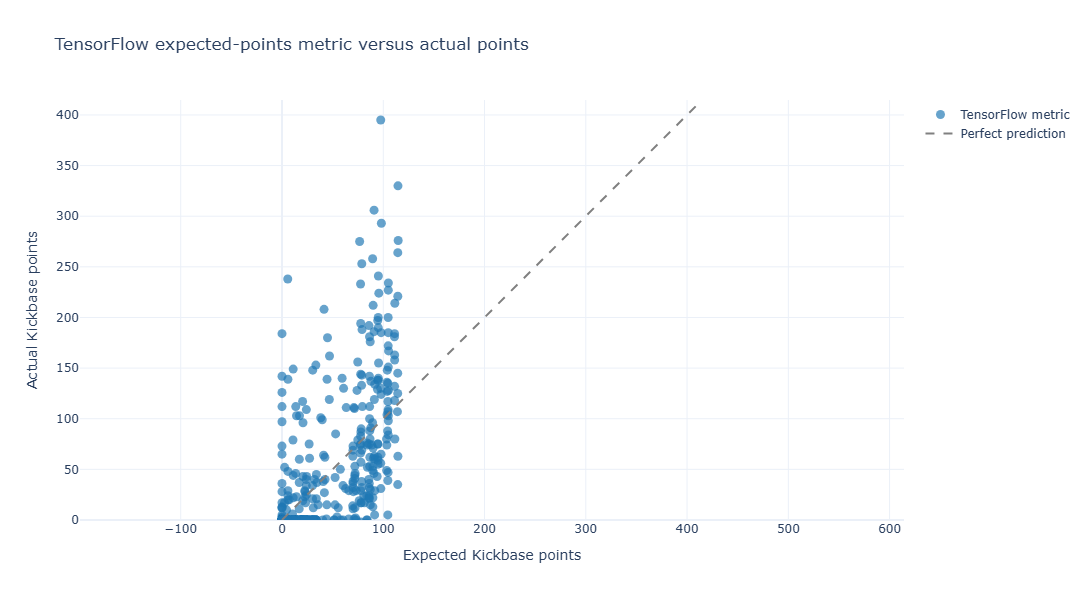

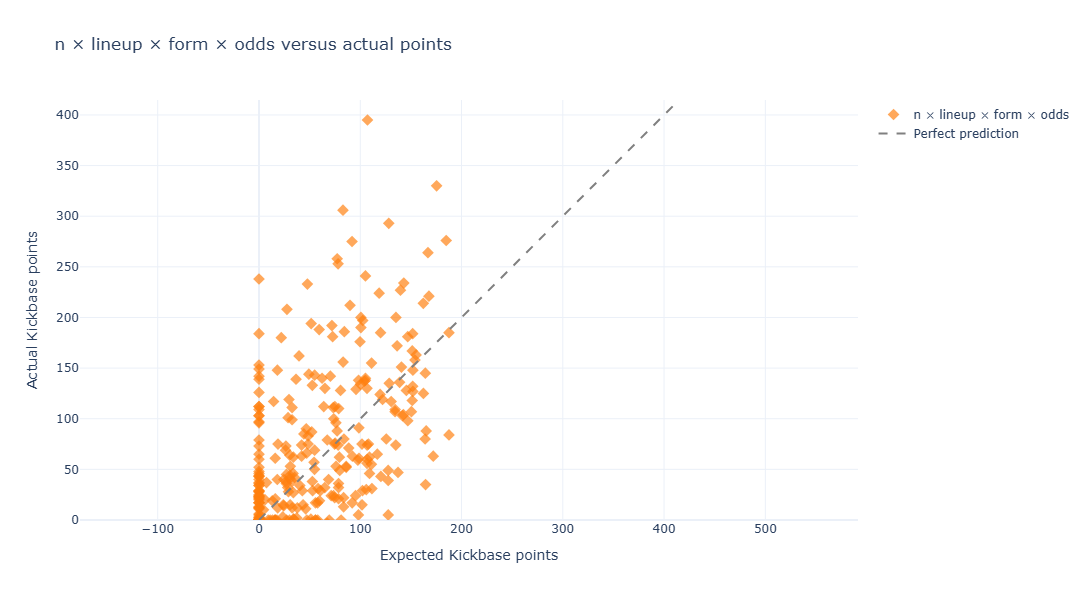

The two charts use the same axes and the same dashed perfect-prediction line for a fair visual comparison. Both metrics are fitted on these rows, so use the holdout results above for the less optimistic check.


In [12]:
# Transform the three learned, standardised weights back into a prediction in actual-points units.
# This uses exactly the fitted one-layer model above (including its intercept), not a new fit.
TENSORFLOW_EXPECTED_POINTS = ANALYSIS.copy()
TENSORFLOW_EXPECTED_POINTS['tensorflow_expected_points'] = np.nan
all_model_rows = MODEL_FRAME.index
all_model_inputs = MODEL_FRAME[list(MODEL_FEATURES.values())]
TENSORFLOW_EXPECTED_POINTS.loc[all_model_rows, 'tensorflow_expected_points'] = (
    SHALLOW_TENSORFLOW_MODEL.predict(
        FEATURE_SCALER.transform(all_model_inputs).astype('float32'), verbose=0
    ).ravel()
)
# Expected Kickbase points cannot be negative.
TENSORFLOW_EXPECTED_POINTS['tensorflow_expected_points'] = (
    TENSORFLOW_EXPECTED_POINTS['tensorflow_expected_points'].clip(lower=0)
)

TENSORFLOW_CHART = TENSORFLOW_EXPECTED_POINTS.dropna(
    subset=['tensorflow_expected_points', 'actual_points']
).copy()
# Fit the requested one-parameter formula: n × lineup score × recent form × odds.
# fit_intercept=False keeps the formula exactly in that form: it learns n and nothing else.
from sklearn.linear_model import LinearRegression
MULTIPLICATIVE_FEATURES = ['starting_chance', 'sofascore_average_rating', 'expected_match_points']
TENSORFLOW_CHART['multiplicative_base'] = TENSORFLOW_CHART[MULTIPLICATIVE_FEATURES].prod(axis=1)
if TENSORFLOW_CHART['multiplicative_base'].nunique() < 2:
    raise ValueError('The multiplicative formula needs at least two distinct lineup × form × odds values.')
MULTIPLICATIVE_REGRESSION = LinearRegression(fit_intercept=False, positive=True)
MULTIPLICATIVE_REGRESSION.fit(
    TENSORFLOW_CHART[['multiplicative_base']], TENSORFLOW_CHART['actual_points']
)
MULTIPLICATIVE_N = float(MULTIPLICATIVE_REGRESSION.coef_[0])
TENSORFLOW_CHART['multiplicative_expected_points'] = (
    MULTIPLICATIVE_N * TENSORFLOW_CHART['multiplicative_base']
).clip(lower=0)

TENSORFLOW_EXPECTED_METRICS = accuracy_metrics(
    TENSORFLOW_CHART['actual_points'], TENSORFLOW_CHART['tensorflow_expected_points']
)
MULTIPLICATIVE_EXPECTED_METRICS = accuracy_metrics(
    TENSORFLOW_CHART['actual_points'], TENSORFLOW_CHART['multiplicative_expected_points']
)
display(pd.DataFrame(
    [TENSORFLOW_EXPECTED_METRICS, MULTIPLICATIVE_EXPECTED_METRICS],
    index=['TensorFlow expected-points metric (all valid rows)', 'n × lineup × form × odds (all valid rows)'],
).round(3))
print(f'Best-fit n: {MULTIPLICATIVE_N:.4f}')

max_axis_value = max(
    TENSORFLOW_CHART['tensorflow_expected_points'].max(),
    TENSORFLOW_CHART['multiplicative_expected_points'].max(),
    TENSORFLOW_CHART['actual_points'].max(),
)
chart_range = [0, max_axis_value * 1.05] if max_axis_value > 0 else [0, 1]

def expected_vs_actual_figure(prediction_column, title, trace_name, marker, customdata, hovertemplate):
    figure = go.Figure()
    figure.add_trace(go.Scatter(
        x=TENSORFLOW_CHART[prediction_column], y=TENSORFLOW_CHART['actual_points'],
        mode='markers', name=trace_name, marker=marker, customdata=customdata, hovertemplate=hovertemplate,
    ))
    figure.add_trace(go.Scatter(
        x=chart_range, y=chart_range, mode='lines', name='Perfect prediction',
        line={'dash': 'dash', 'color': 'gray'}, hoverinfo='skip',
    ))
    figure.update_layout(
        title=title, xaxis_title='Expected Kickbase points', yaxis_title='Actual Kickbase points',
        template='plotly_white', height=600,
    )
    figure.update_xaxes(range=chart_range)
    figure.update_yaxes(range=chart_range, scaleanchor='x', scaleratio=1)
    return figure

TENSORFLOW_HOVER = (
    '<b>%{customdata[0]}</b><br>'
    'TensorFlow expected points: %{x:.1f}<br>'
    'Actual points: %{y:.1f}<br>'
    'Raw score: %{customdata[1]:.2f}<br>'
    'Total lineup score: %{customdata[2]:.2f}<br>'
    'SofaScore average rating: %{customdata[3]:.2f}<br>'
    'Odds expected match points: %{customdata[4]:.2f}<br>'
    'LigaInsider / Kickbase / Kicker / RotoWire: %{customdata[5]:.2f} / %{customdata[6]:.2f} / %{customdata[7]:.2f} / %{customdata[8]:.2f}<br>'
    'Played / started / minutes: %{customdata[9]} / %{customdata[10]} / %{customdata[11]:.0f}<extra></extra>'
)
PRODUCT_HOVER = (
    '<b>%{customdata[0]}</b><br>'
    'Product-formula expected points: %{x:.1f}<br>'
    'Actual points: %{y:.1f}<br>'
    f'Formula: {MULTIPLICATIVE_N:.4f} × lineup score × recent form × odds<br>'
    'Lineup score / recent form / odds: %{customdata[2]:.2f} / %{customdata[3]:.2f} / %{customdata[4]:.2f}<br>'
    'Played / started / minutes: %{customdata[5]} / %{customdata[6]} / %{customdata[7]:.0f}<extra></extra>'
)

tensorflow_expected_points_figure = expected_vs_actual_figure(
    'tensorflow_expected_points', 'TensorFlow expected-points metric versus actual points',
    'TensorFlow metric', {'size': 9, 'opacity': 0.68, 'color': '#1f77b4'},
    TENSORFLOW_CHART[[
        'name', 'prediction', 'starting_chance', 'sofascore_average_rating',
        'expected_match_points', 'ligainsider_chance', 'kickbase_chance',
        'kicker_chance', 'rotowire_chance', 'played', 'started', 'minutes_played',
    ]],
    TENSORFLOW_HOVER,
)
multiplicative_expected_points_figure = expected_vs_actual_figure(
    'multiplicative_expected_points', 'n × lineup × form × odds versus actual points',
    'n × lineup × form × odds',
    {'size': 9, 'opacity': 0.68, 'color': '#ff7f0e', 'symbol': 'diamond'},
    TENSORFLOW_CHART[[
        'name', 'multiplicative_base', 'starting_chance', 'sofascore_average_rating',
        'expected_match_points', 'played', 'started', 'minutes_played',
    ]],
    PRODUCT_HOVER,
)
tensorflow_expected_points_figure.show()
multiplicative_expected_points_figure.show()
print(
    'The two charts use the same axes and the same dashed perfect-prediction line for a fair visual comparison. '
    'Both metrics are fitted on these rows, so use the holdout results above for the less optimistic check.'
)

,prediction_decile,players,mean_prediction,mean_actual
0,1,47,0.00,8.40
1,2,47,0.00,14.94
2,3,47,0.00,15.72
3,4,47,0.00,5.66
4,5,47,0.00,13.79
5,6,46,1.89,33.24
6,7,47,4.49,54.91
7,8,47,7.52,74.94
8,9,47,10.67,105.64
9,10,47,15.66,134.87


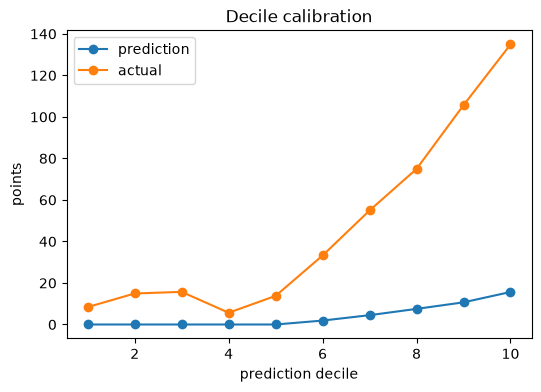

In [13]:
ANALYSIS['prediction_decile'] = pd.qcut(ANALYSIS['prediction'].rank(method='first'), q=10, labels=False) + 1
CALIBRATION = ANALYSIS.groupby('prediction_decile', observed=True).agg(
    players=('player_id', 'size'), mean_prediction=('prediction', 'mean'), mean_actual=('actual_points', 'mean')
).reset_index()
display(CALIBRATION.round(2))
plt.figure(figsize=(6, 4))
plt.plot(CALIBRATION['prediction_decile'], CALIBRATION['mean_prediction'], marker='o', label='prediction')
plt.plot(CALIBRATION['prediction_decile'], CALIBRATION['mean_actual'], marker='o', label='actual')
plt.xlabel('prediction decile'); plt.ylabel('points'); plt.title('Decile calibration'); plt.legend(); plt.show()

## Commit the next-matchday baseline

This confirmation protects the only persistent write. It updates no score files; it only saves the current cumulative player totals for comparison with the next KBStats snapshot. A selected historical KBStats snapshot can never replace a newer saved baseline.

In [14]:
baseline_snapshot_times = pd.to_datetime(BASELINE.get('snapshot_timestamp'), utc=True, errors='coerce')
newest_saved_baseline_time = baseline_snapshot_times.max() if len(baseline_snapshot_times) else pd.NaT
selected_snapshot_is_older = (
    pd.notna(newest_saved_baseline_time)
    and INPUTS.kbstats_created_at < newest_saved_baseline_time.to_pydatetime()
)

if selected_snapshot_is_older:
    print(
        'Baseline not updated: the selected KBStats snapshot is older than the saved baseline. '
        'This keeps future matchday comparisons safe.'
    )
else:
    update_baseline = input(
        'Update the player baseline for the next matchday? Type yes to confirm: '
    ).strip().casefold() == 'yes'
    if update_baseline:
        NEXT_BASELINE = baseline_from_snapshot(CURRENT, INPUTS.kbstats_created_at, INPUTS.kbstats_path)
        persist_baseline(NEXT_BASELINE)
        print(f'Updated baseline: {BASELINE_PATH}')
    else:
        print('Baseline not updated.')

Update the player baseline for the next matchday? Type yes to confirm:  yes


Updated baseline: C:\kickbase project\data\reference\kbstats_player_match_baseline.csv
